<a href="https://colab.research.google.com/github/komalprashar790-cmyk/Machine-Learning-model/blob/main/K_NN.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

K-NN training model
KNN is a (k-nearest neighbors) is a simple and widely used algorithm in ML for both classification and regression tasks.

Starbuck _customer _ordering _pattern

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# importing the dataset
data = pd.read_csv("/content/starbucks_customer_ordering_patterns.csv.xls")
print(data.head())

# cleaning the data
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
# KNN  model
from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score

from sklearn.preprocessing import StandardScaler
sc = StandardScaler()



# define different feature and make pipelines
categorical_features = ["region","is_rewards_member","customer_gender","drink_category", "customer_age_group"]

categorical_transformer = Pipeline(steps= [("imputer",SimpleImputer(strategy="constant",fill_value='missing')),
                                           ("onehot",OneHotEncoder(handle_unknown="ignore"))])

numerical_features= ["cart_size","total_spend","fulfillment_time_min","customer_satisfaction","num_customizations"]
numerical_transformer = Pipeline(steps=[("imputer",SimpleImputer(strategy='mean'))])

# setup processing step
processor = ColumnTransformer(transformers=[("cat", categorical_transformer, categorical_features),
                                            ("num", numerical_transformer, numerical_features)
])

# model
model = Pipeline(steps=[("processor",processor),
                        ("model",KNeighborsClassifier(n_neighbors=5,metric="minkowski"))

])
#splits  and train data
x = data.drop("order_channel",axis=1)
y = data["order_channel"]
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.2, random_state=42)
#fit and score the model
model.fit(x_train,y_train)
model.score(x_test,y_test)

#predicting a result
y_pred =model.predict(x_test)
print("predicted",y_pred)
print(np.concatenate((y_pred.reshape(len(y_pred),1),y_test.values.reshape(len(y_test),1))))
print("accuracy",model.score(x_test,y_test))



  customer_id      order_id  order_date order_time day_of_week order_channel  \
0  CUST_12974  ORD_00000001  25-03-2024      08:47         Mon    Drive-Thru   
1  CUST_08235  ORD_00000002  18-07-2025      08:02         Fri    Mobile App   
2  CUST_00393  ORD_00000003  15-01-2025      05:40         Wed         Kiosk   
3  CUST_06936  ORD_00000004  30-07-2024      15:10         Tue    Drive-Thru   
4  CUST_09800  ORD_00000005  18-06-2024      07:38         Tue    Drive-Thru   

  store_id store_location_type     region customer_age_group customer_gender  \
0  STR_340            Suburban  Southwest              18-24            Male   
1  STR_425               Urban  Northeast              35-44          Female   
2  STR_103            Suburban    Midwest              25-34          Female   
3  STR_318            Suburban    Midwest              25-34          Female   
4  STR_338            Suburban  Northeast              35-44          Female   

   is_rewards_member  cart_size  num_c

starbuck_customer_ordering_patterns using descision model


  customer_id      order_id  order_date order_time day_of_week order_channel  \
0  CUST_12974  ORD_00000001  25-03-2024      08:47         Mon    Drive-Thru   
1  CUST_08235  ORD_00000002  18-07-2025      08:02         Fri    Mobile App   
2  CUST_00393  ORD_00000003  15-01-2025      05:40         Wed         Kiosk   
3  CUST_06936  ORD_00000004  30-07-2024      15:10         Tue    Drive-Thru   
4  CUST_09800  ORD_00000005  18-06-2024      07:38         Tue    Drive-Thru   

  store_id store_location_type     region customer_age_group customer_gender  \
0  STR_340            Suburban  Southwest              18-24            Male   
1  STR_425               Urban  Northeast              35-44          Female   
2  STR_103            Suburban    Midwest              25-34          Female   
3  STR_318            Suburban    Midwest              25-34          Female   
4  STR_338            Suburban  Northeast              35-44          Female   

   is_rewards_member  cart_size  num_c

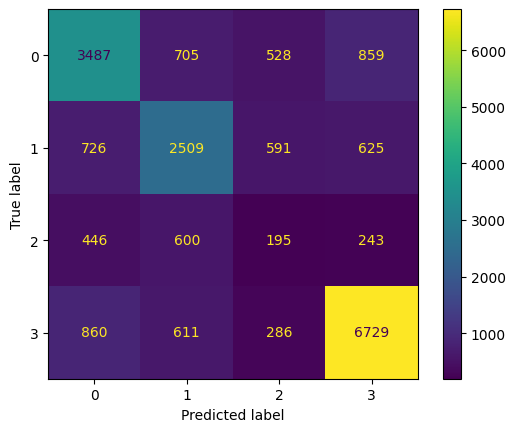

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# importing the dataset
data = pd.read_csv("/content/starbucks_customer_ordering_patterns.csv.xls")
print(data.head())

# cleaning the data
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
# decision tree classifer
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score

from sklearn.preprocessing import StandardScaler
sc = StandardScaler()



# define different feature and make pipelines
categorical_features = ["region","is_rewards_member","customer_gender","drink_category", "customer_age_group"]

categorical_transformer = Pipeline(steps= [("imputer",SimpleImputer(strategy="constant",fill_value='missing')),
                                           ("onehot",OneHotEncoder(handle_unknown="ignore"))])

numerical_features= ["cart_size","total_spend","fulfillment_time_min","customer_satisfaction","num_customizations"]
numerical_transformer = Pipeline(steps=[("imputer",SimpleImputer(strategy='mean'))])

# setup processing step
processor = ColumnTransformer(transformers=[("cat", categorical_transformer, categorical_features),
                                            ("num", numerical_transformer, numerical_features)
])

# model
model = Pipeline(steps=[("processor",processor),
                        ("model",DecisionTreeClassifier())

])
#splits  and train data
x = data.drop("order_channel",axis=1)
y = data["order_channel"]
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.2, random_state=42)
#fit and score the model
model.fit(x_train,y_train)
model.score(x_test,y_test)

#predicting a result
y_pred =model.predict(x_test)
print("predicted",y_pred)
print(np.concatenate((y_pred.reshape(len(y_pred),1),y_test.values.reshape(len(y_test),1))))
print("accuracy",model.score(x_test,y_test))

# confusion matrix:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

# Predict values
y_pred = model.predict(x_test)

# Create confusion matrix
cm = confusion_matrix(y_test, y_pred)

# Display confusion matrix
disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot()

plt.show()


starbuck _customer _ordering using random forest classifier

  customer_id      order_id  order_date order_time day_of_week order_channel  \
0  CUST_12974  ORD_00000001  25-03-2024      08:47         Mon    Drive-Thru   
1  CUST_08235  ORD_00000002  18-07-2025      08:02         Fri    Mobile App   
2  CUST_00393  ORD_00000003  15-01-2025      05:40         Wed         Kiosk   
3  CUST_06936  ORD_00000004  30-07-2024      15:10         Tue    Drive-Thru   
4  CUST_09800  ORD_00000005  18-06-2024      07:38         Tue    Drive-Thru   

  store_id store_location_type     region customer_age_group customer_gender  \
0  STR_340            Suburban  Southwest              18-24            Male   
1  STR_425               Urban  Northeast              35-44          Female   
2  STR_103            Suburban    Midwest              25-34          Female   
3  STR_318            Suburban    Midwest              25-34          Female   
4  STR_338            Suburban  Northeast              35-44          Female   

   is_rewards_member  cart_size  num_c

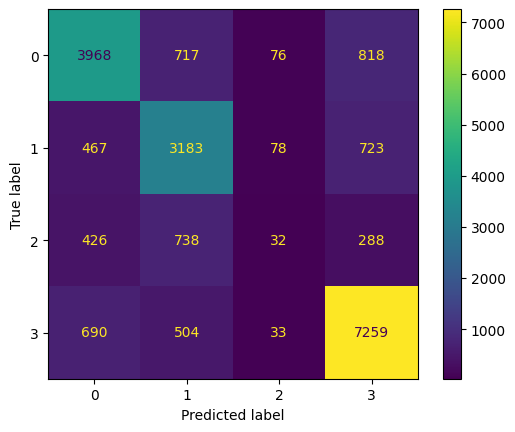

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# importing the dataset
data = pd.read_csv("/content/starbucks_customer_ordering_patterns.csv.xls")
print(data.head())

# cleaning the data
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
# decision tree classifer
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score

from sklearn.preprocessing import StandardScaler
sc = StandardScaler()



# define different feature and make pipelines
categorical_features = ["region","is_rewards_member","customer_gender","drink_category", "customer_age_group"]

categorical_transformer = Pipeline(steps= [("imputer",SimpleImputer(strategy="constant",fill_value='missing')),
                                           ("onehot",OneHotEncoder(handle_unknown="ignore"))])

numerical_features= ["cart_size","total_spend","fulfillment_time_min","customer_satisfaction","num_customizations"]
numerical_transformer = Pipeline(steps=[("imputer",SimpleImputer(strategy='mean'))])

# setup processing step
processor = ColumnTransformer(transformers=[("cat", categorical_transformer, categorical_features),
                                            ("num", numerical_transformer, numerical_features)
])

# model
model = Pipeline(steps=[("processor",processor),
                        ("model",RandomForestClassifier())

])
#splits  and train data
x = data.drop("order_channel",axis=1)
y = data["order_channel"]
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.2, random_state=42)
#fit and score the model
model.fit(x_train,y_train)
model.score(x_test,y_test)

#predicting a result
y_pred =model.predict(x_test)
print("predicted",y_pred)
print(np.concatenate((y_pred.reshape(len(y_pred),1),y_test.values.reshape(len(y_test),1))))
print("accuracy",model.score(x_test,y_test))

# confusion matrix:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

# Predict values
y_pred = model.predict(x_test)

# Create confusion matrix
cm = confusion_matrix(y_test, y_pred)

# Display confusion matrix
disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot()

plt.show()
